# Analisis Clustering Komentar TikTok Pada Kekalahan RRQ di MPL ID S15 Menggunakan DBSCAN, Agglomerative Hierarchical, K-Means, Fuzzy C-Means Clustering

In [3]:
!pip install scikit-fuzzy
!pip install wordcloud

## IMPORT LIBRARY

In [5]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz

import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from gensim.models import Word2Vec

from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.feature_extraction.text import CountVectorizer
from tqdm import tqdm

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pramu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pramu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## LOAD DATASET

In [7]:
df = pd.read_csv("dataset_tiktok-comments-scraper-mplid.csv")


df = df[['text']].dropna()
df = df[df['text'].str.strip() != '']  # hilangkan komentar kosong
df.reset_index(drop=True, inplace=True)

df.head(10).rename(index=lambda x: x + 1)

,text
1,"rrq is strong, but i hate it when they're star..."
2,keep strong RRQ 😇\nrespect dri sonic 💛🧡
3,King of Runner Up
4,Runner up from RRQ🗿
5,introboys
6,rrq most consistent top 2 placer in mpl id😭
7,"the greatest 2nd place finisher of all time, R..."
8,RRQ Till I die🧡🧡🧡
9,yve pick game 7 curse
10,it's onic time....


#### Dataset berisi 2.500 komentar dari unggahan video di akun TikTok resmi MPL Indonesia terkait kekalahan tim RRQ dari ONIC di MPL ID S15. Kolom yang digunakan hanya text, yang berisi komentar dari pengguna.

In [8]:
slang_dict = {
    'gw': 'saya', 'gue': 'saya', 'gua': 'saya', 'lu': 'kamu', 'loe': 'kamu',
    'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'tdk': 'tidak',
    'bgt': 'banget', 'wkwk': 'haha', 'anj': 'anjing', 'jg': 'juga',
    'tp': 'tapi', 'yg': 'yang', 'dr': 'dari', 'dgn': 'dengan', 'sdh': 'sudah', 'GG': 'Main Bagus',
    'gg': 'Main Bagus'
}

def replace_slang(text):
    return ' '.join([slang_dict.get(word, word) for word in text.split()])

df['text'] = df['text'].apply(replace_slang)

#### Menggantikan kata tidak baku (slang) dengan bentuk formal. Ini penting karena slang sering muncul di media sosial dan dapat menurunkan kualitas tokenisasi dan pemaknaan dalam Word2Vec.

## PRE-PROCESSING

In [10]:
stop_words = set(stopwords.words('indonesian'))
factory = StemmerFactory()
stemmer = factory.create_stemmer()


def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # hapus non-alfabetik
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    stems = [stemmer.stem(t) for t in tokens]
    return stems

# Simpan hasil preprocessing
df['tokens'] = df['text'].apply(clean_text)
df.head(10)

,text,tokens
0,"rrq is strong, but i hate it when they're star...","[rrq, is, strong, but, i, hate, it, when, they..."
1,keep strong RRQ 😇 respect dri sonic 💛🧡,"[keep, strong, rrq, respect, dri, sonic]"
2,King of Runner Up,"[king, of, runner, up]"
3,Runner up from RRQ🗿,"[runner, up, from, rrq]"
4,introboys,[introboys]
5,rrq most consistent top 2 placer in mpl id😭,"[rrq, most, consistent, top, placer, in, mpl, id]"
6,"the greatest 2nd place finisher of all time, R...","[the, greatest, nd, place, finisher, of, all, ..."
7,RRQ Till I die🧡🧡🧡,"[rrq, till, i, die]"
8,yve pick game 7 curse,"[yve, pick, game, curse]"
9,it's onic time....,"[its, onic, time]"


##### 1. Lowercasing dan penghapusan karakter non-alfabetik menjaga konsistensi.
##### 2. Stopword removal menghilangkan kata-kata umum yang tidak membawa informasi penting.
##### 3. Stemming (Sastrawi) menyatukan variasi kata ke bentuk dasar agar model tidak memperlakukan “kalah” dan “kalahkan” sebagai kata berbeda.

In [11]:
# Hapus komentar yang jumlah katanya < 2 atau terlalu sedikit
df = df[df['tokens'].apply(lambda x: len(x) >= 2)]
df.reset_index(drop=True, inplace=True)

#### Komentar dengan jumlah token kurang dari dua dianggap tidak informatif dan dibuang untuk menjaga kualitas data.

## REPRESENTASI FITUR MENGGUNAKAN WORD2VEC

In [13]:
model = Word2Vec(sentences=df['tokens'], vector_size=64, window=5, min_count=2, workers=4)
model.train(df['tokens'], total_examples=len(df), epochs=10)

# Ambil representasi vektor tiap komentar dengan rata-rata embedding katanya
def get_vector(tokens):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(64)

df['vector'] = df['tokens'].apply(get_vector)
X = np.vstack(df['vector'].values)

#### Model Word2Vec digunakan karena dapat menangkap semantik kata berdasarkan konteks penggunaannya.
* vector_size=64: Ukuran vektor kata. Dipilih 64 agar cukup representatif namun ringan secara komputasi.
* window=5: Konteks sejauh 5 kata kiri-kanan digunakan untuk belajar hubungan kata.
* min_count=2: Kata yang muncul hanya 1 kali tidak dimasukkan karena dianggap tidak cukup penting

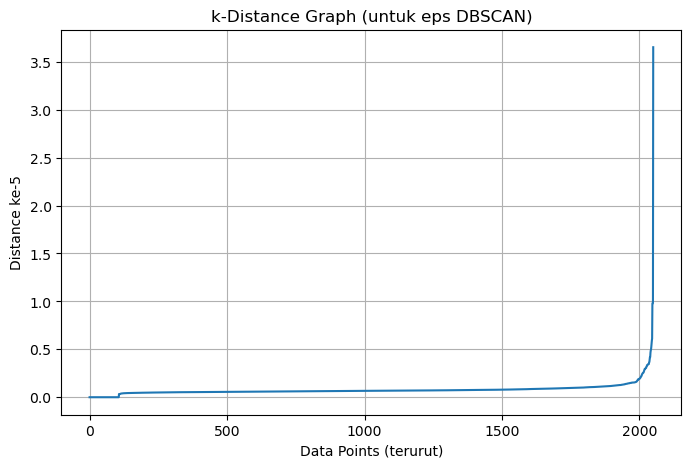

In [14]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5  
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Ambil kolom ke-k (jarak ke tetangga ke-5), lalu sort
k_distances = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title('k-Distance Graph (untuk eps DBSCAN)')
plt.xlabel('Data Points (terurut)')
plt.ylabel(f'Distance ke-{min_samples}')
plt.grid(True)
plt.show()

#### Digunakan untuk menentukan nilai epsilon (eps) pada DBSCAN dengan memvisualisasi k-distance graph. Titik lutut grafik menunjukkan jarak maksimum antar titik yang masih bisa dianggap dalam satu cluster. Nilai min_samples=5 dipilih sebagai nilai umum minimum tetangga di DBSCAN.

In [15]:
eps_value = 0.95

## CLUSTERING

### 1. DBSCAN CLUSTERING

In [16]:
# Clustering - DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5, metric='euclidean')
df['cluster_dbscan'] = dbscan.fit_predict(X)

### 2. AGGLOMERATIVE HIERARCHICAL CLUSTERING

In [17]:
# === Silhouette Score Loop untuk menentukan jumlah cluster terbaik (Agglo) ===
sil_scores = {}
print("Silhouette Scores untuk berbagai jumlah cluster:")
for k in range(2, 7):
    agglo_temp = AgglomerativeClustering(n_clusters=k)
    labels = agglo_temp.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores[k] = score
    print(f"n_clusters = {k}, Silhouette = {score:.4f}")

# Pilih n_clusters dengan skor tertinggi
optimal_n_clusters = max(sil_scores, key=sil_scores.get)
print(f"\nJumlah cluster optimal Agglo berdasarkan Silhouette: {optimal_n_clusters}")

Silhouette Scores untuk berbagai jumlah cluster:
n_clusters = 2, Silhouette = 0.4992
n_clusters = 3, Silhouette = 0.4406
n_clusters = 4, Silhouette = 0.4124
n_clusters = 5, Silhouette = 0.4158
n_clusters = 6, Silhouette = 0.3332

Jumlah cluster optimal Agglo berdasarkan Silhouette: 2


In [18]:
# Clustering - Agglomerative
agglo = AgglomerativeClustering(n_clusters=optimal_n_clusters)
df['cluster_agglo'] = agglo.fit_predict(X)

### 3. K-MEANS CLUSTERING

In [19]:
# K-Means Clustering
print("\n=== K-Means Clustering ===")
sil_scores_kmeans = {}
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores_kmeans[k] = score
    print(f"n_clusters = {k}, Silhouette = {score:.4f}")

optimal_k_kmeans = max(sil_scores_kmeans, key=sil_scores_kmeans.get)
print(f"\nOptimal jumlah cluster KMeans berdasarkan Silhouette: {optimal_k_kmeans}")

kmeans = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X)


=== K-Means Clustering ===
n_clusters = 2, Silhouette = 0.5011
n_clusters = 3, Silhouette = 0.4658
n_clusters = 4, Silhouette = 0.4094
n_clusters = 5, Silhouette = 0.4105
n_clusters = 6, Silhouette = 0.3848

Optimal jumlah cluster KMeans berdasarkan Silhouette: 2


### 4. FUZZY C-MEANS CLUSTERING

In [20]:
# Fuzzy C-Means
print("\n=== Fuzzy C-Means Clustering ===")
X_scaled = MinMaxScaler().fit_transform(X)  

# Fuzzy C-Means with cluster = 2 to 10
fcm_sil_scores = {}
for k in range(2, 7):
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(X_scaled.T, c=k, m=2.0, error=0.005, maxiter=1000, init=None)
    labels = np.argmax(u, axis=0)
    score = silhouette_score(X_scaled, labels)
    fcm_sil_scores[k] = score
    print(f"n_clusters = {k}, Silhouette = {score:.4f}")

optimal_k_fcm = max(fcm_sil_scores, key=fcm_sil_scores.get)
print(f"\nOptimal jumlah cluster FCM berdasarkan Silhouette: {optimal_k_fcm}")

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(X_scaled.T, c=optimal_k_fcm, m=2.0, error=0.005, maxiter=1000, init=None)
labels_fcm = np.argmax(u, axis=0)
df['cluster_fcm'] = labels_fcm


=== Fuzzy C-Means Clustering ===
n_clusters = 2, Silhouette = 0.4459
n_clusters = 3, Silhouette = 0.3842
n_clusters = 4, Silhouette = 0.3323
n_clusters = 5, Silhouette = 0.2867
n_clusters = 6, Silhouette = 0.2402

Optimal jumlah cluster FCM berdasarkan Silhouette: 2


## EVALUASI

In [21]:
# Evaluasi Internal
print("DBSCAN Silhouette Score:", silhouette_score(X, df['cluster_dbscan']))
print("DBSCAN Davies-Bouldin Index:", davies_bouldin_score(X, df['cluster_dbscan']))
print("================================================")
print("Agglomerative Silhouette Score:", silhouette_score(X, df['cluster_agglo']))
print("Agglomerative Davies-Bouldin Index:", davies_bouldin_score(X, df['cluster_agglo']))
print("================================================")
print("KMeans Silhouette Score:", silhouette_score(X, df['cluster_kmeans']))
print("KMeans Davies-Bouldin Index:", davies_bouldin_score(X, df['cluster_kmeans']))
print("================================================")
print("FCM Silhouette Score:", silhouette_score(X_scaled, df['cluster_fcm']))
print("FCM Davies-Bouldin Index:", davies_bouldin_score(X_scaled, df['cluster_fcm']))

DBSCAN Silhouette Score: 0.8885853541527008
DBSCAN Davies-Bouldin Index: 0.0768844470855702
Agglomerative Silhouette Score: 0.49924822214228126
Agglomerative Davies-Bouldin Index: 0.7243257393488204
KMeans Silhouette Score: 0.501084861346046
KMeans Davies-Bouldin Index: 0.7230021535015658
FCM Silhouette Score: 0.4459469715078297
FCM Davies-Bouldin Index: 0.8181096695927086


### DENDOGRAM

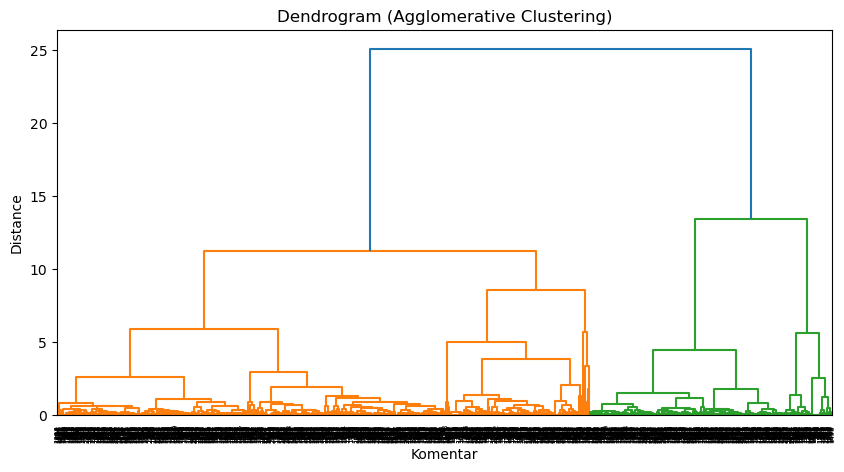

In [22]:
# Dendrogram untuk Hierarchical
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendrogram (Agglomerative Clustering)")
plt.xlabel("Komentar")
plt.ylabel("Distance")
plt.show()

# VISUALISASI CLUSTER

## T-SNE DBSCAN

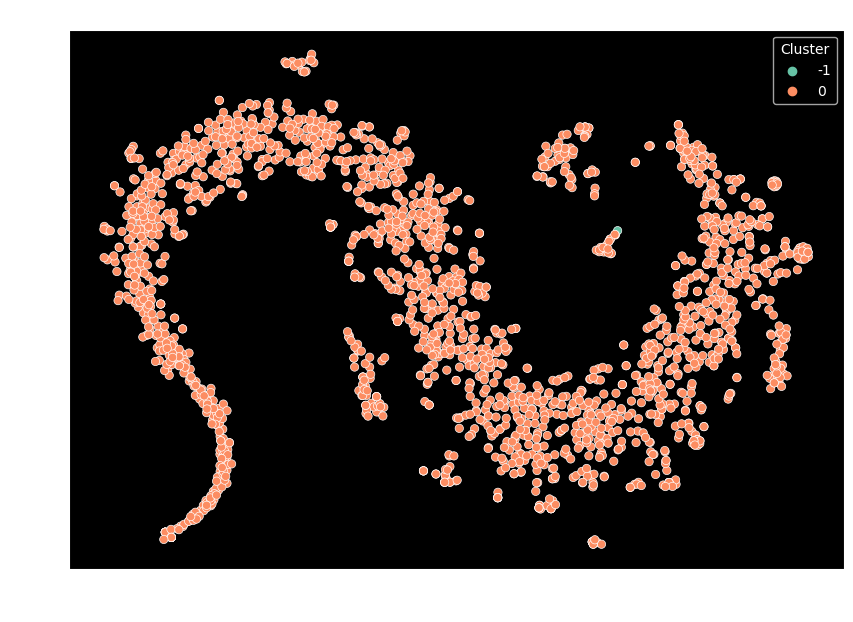

In [23]:
tsne_dbscan = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_dbscan = tsne_dbscan.fit_transform(X)

# Visualisasi hasil clustering DBSCAN
plt.figure(figsize=(10, 7))
plt.style.use('dark_background')
sns.scatterplot(x=X_tsne_dbscan[:, 0], y=X_tsne_dbscan[:, 1], hue=df['cluster_dbscan'], palette='Set2')
plt.title("t-SNE Visualization of Clusters (DBSCAN)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster")
plt.show()

## PCA DBSCAN

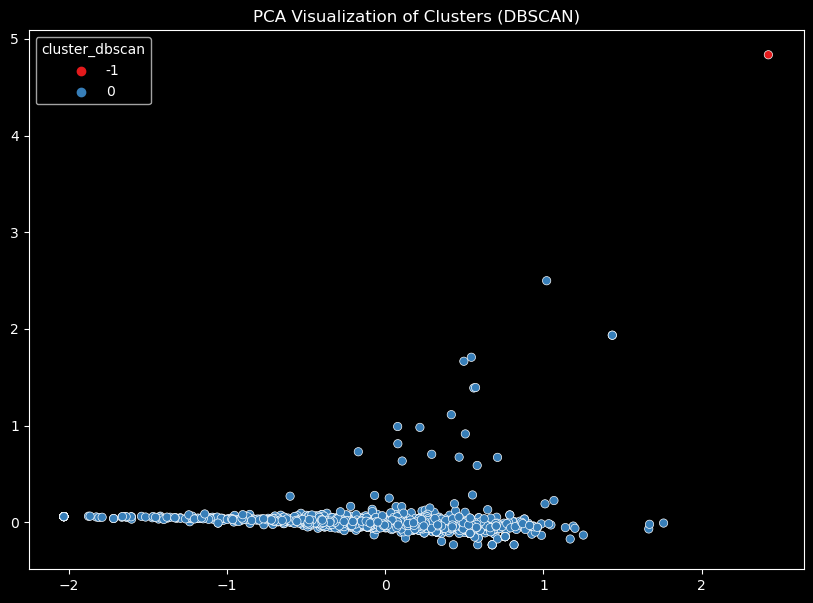

In [24]:
# PCA untuk DBSCAN
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
plt.style.use('dark_background')
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster_dbscan'], palette='Set1')
plt.title("PCA Visualization of Clusters (DBSCAN)")
plt.show()

## T-SNE AGGLOMERATIVE

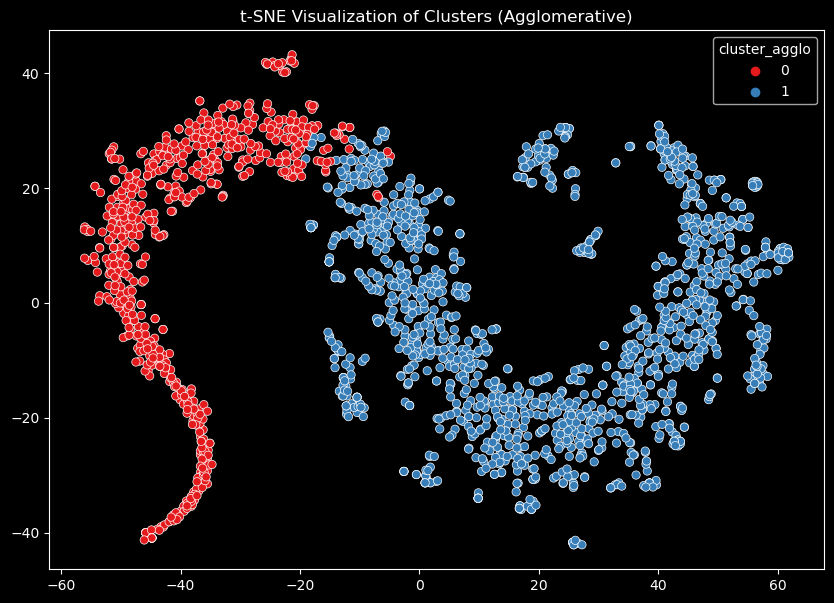

In [25]:
# Visualisasi 2D dengan t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 7))
plt.style.use('dark_background')
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['cluster_agglo'], palette='Set1')
plt.title("t-SNE Visualization of Clusters (Agglomerative)")
plt.show()

## PCA AGGLOMERATIVE

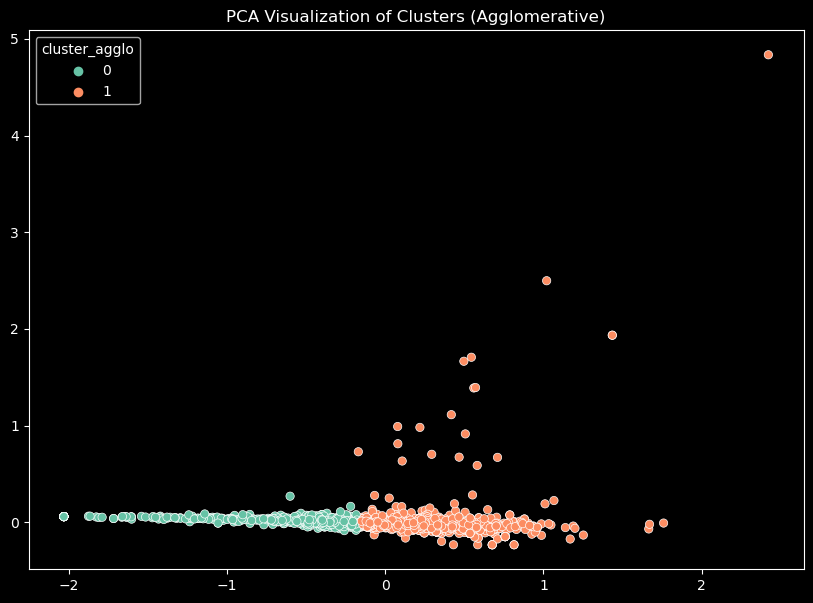

In [26]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
plt.style.use('dark_background')
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster_agglo'], palette='Set2')
plt.title("PCA Visualization of Clusters (Agglomerative)")
plt.show()

## T-SNE K-MEANS

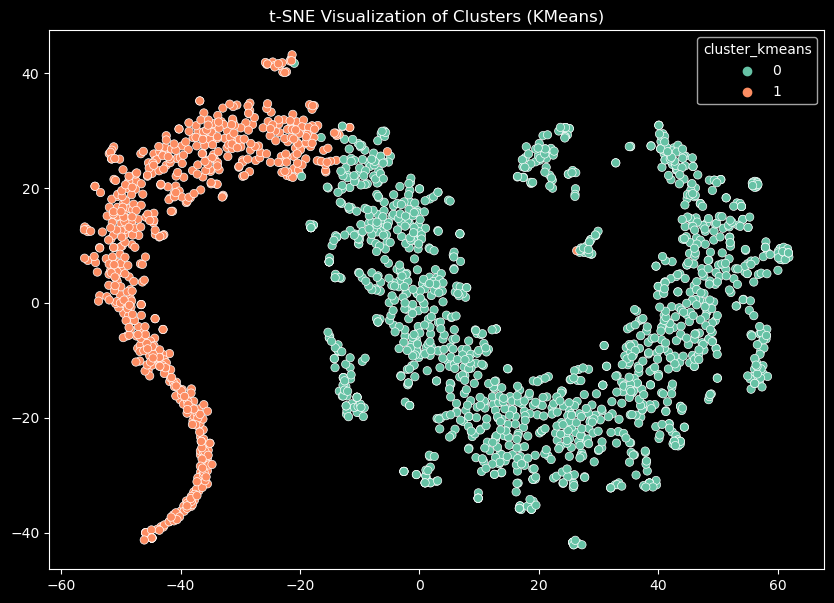

In [27]:
# t-SNE Visual KMeans
tsne_kmeans = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_kmeans = tsne_kmeans.fit_transform(X)

plt.figure(figsize=(10, 7))
plt.style.use('dark_background')
sns.scatterplot(x=X_tsne_kmeans[:, 0], y=X_tsne_kmeans[:, 1], hue=df['cluster_kmeans'], palette='Set2')
plt.title("t-SNE Visualization of Clusters (KMeans)")
plt.show()

## PCA K-MEANS

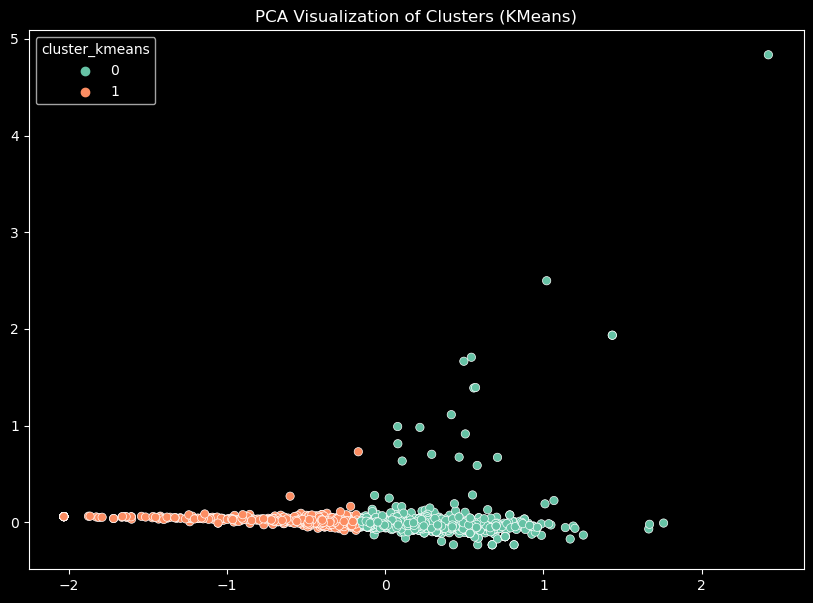

In [28]:
# PCA Visual KMeans
pca = PCA(n_components=2)
X_pca_kmeans = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
plt.style.use('dark_background')
sns.scatterplot(x=X_pca_kmeans[:, 0], y=X_pca_kmeans[:, 1], hue=df['cluster_kmeans'], palette='Set2')
plt.title("PCA Visualization of Clusters (KMeans)")
plt.show()

## T-SNE FUZZY C-MEANS

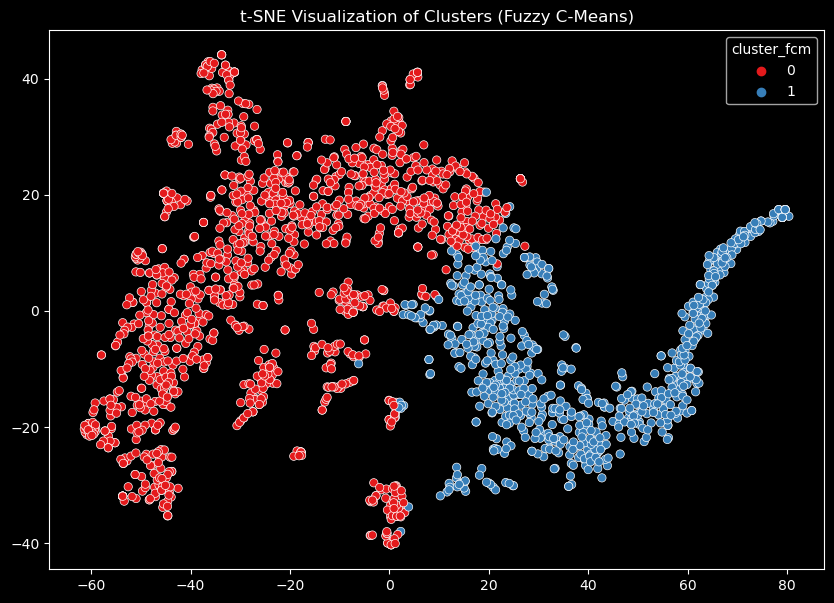

In [29]:
# t-SNE Visual FCM
tsne_fcm = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_fcm = tsne_fcm.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.style.use('dark_background')
sns.scatterplot(x=X_tsne_fcm[:, 0], y=X_tsne_fcm[:, 1], hue=df['cluster_fcm'], palette='Set1')
plt.title("t-SNE Visualization of Clusters (Fuzzy C-Means)")
plt.show()

## PCA FUZZY C-MEANS

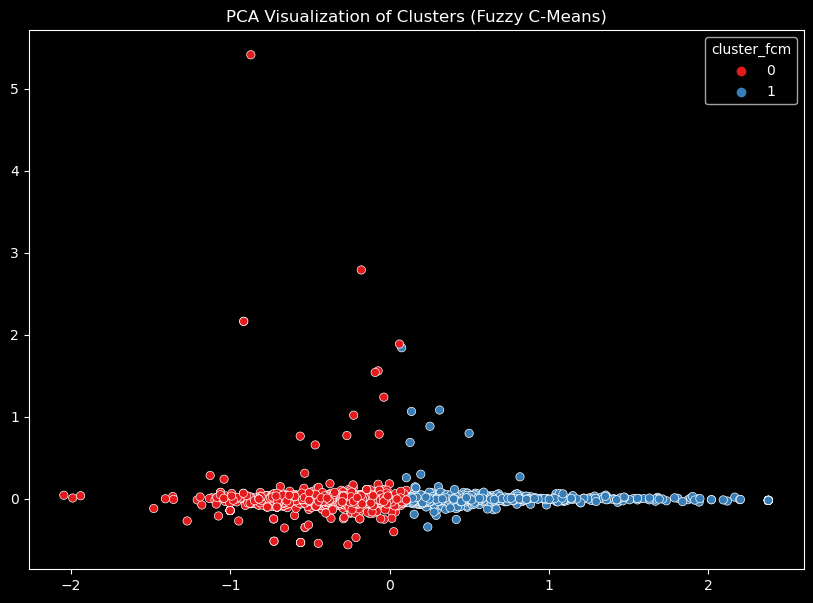

In [30]:
# PCA Visual FCM
X_pca_fcm = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.style.use('dark_background')
sns.scatterplot(x=X_pca_fcm[:, 0], y=X_pca_fcm[:, 1], hue=df['cluster_fcm'], palette='Set1')
plt.title("PCA Visualization of Clusters (Fuzzy C-Means)")
plt.show()

## TOP WORDS TIAP CLUSTER

### TOP WORDS DBSCAN


=== WordCloud per Cluster (DBSCAN) ===

Cluster -1 (Noise):


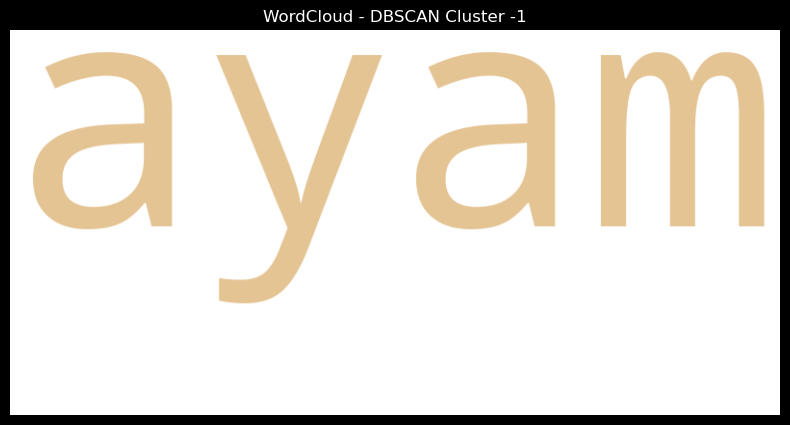


Cluster 0:


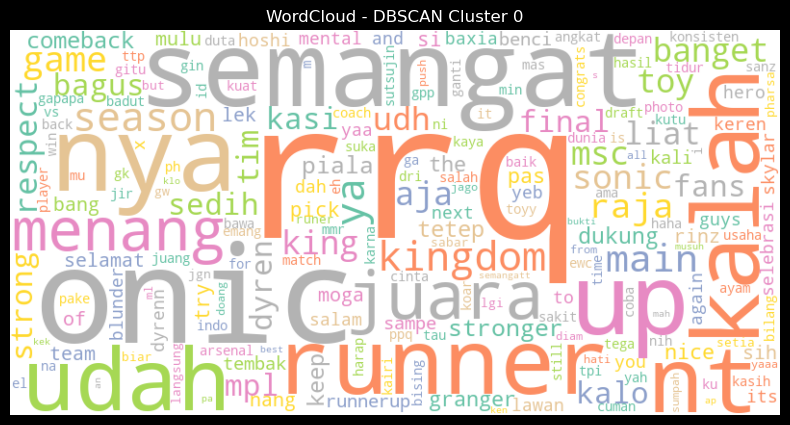

In [31]:
# === Top Words WordCloud untuk DBSCAN ===
print("\n=== WordCloud per Cluster (DBSCAN) ===")
clusters_db = sorted(df['cluster_dbscan'].unique())

for cluster_id in clusters_db:
    if cluster_id == -1:
        print(f"\nCluster {cluster_id} (Noise):")
    else:
        print(f"\nCluster {cluster_id}:")

    tokens_in_cluster = df[df['cluster_dbscan'] == cluster_id]['tokens'].tolist()
    all_words = sum(tokens_in_cluster, [])
    word_freq = Counter(all_words)

    # Buat WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Set2').generate_from_frequencies(word_freq)

    # Tampilkan WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - DBSCAN Cluster {cluster_id}")
    plt.show()

### TOP WORDS AGGLOMERATIVE


=== WordCloud per Cluster (Agglomerative Clustering) ===

Cluster 0:


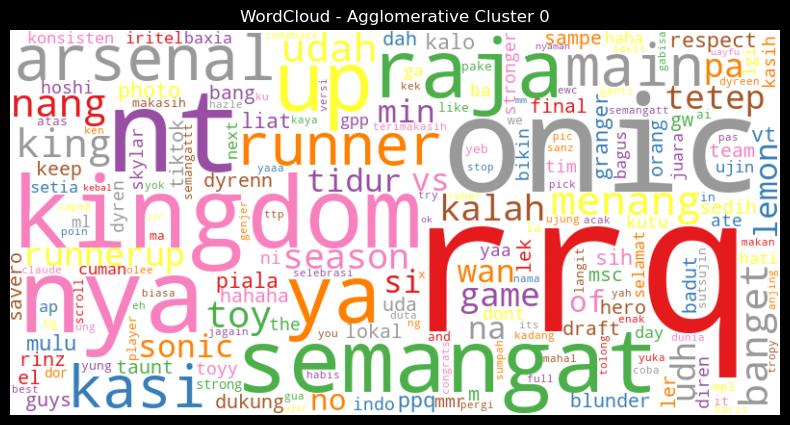


Cluster 1:


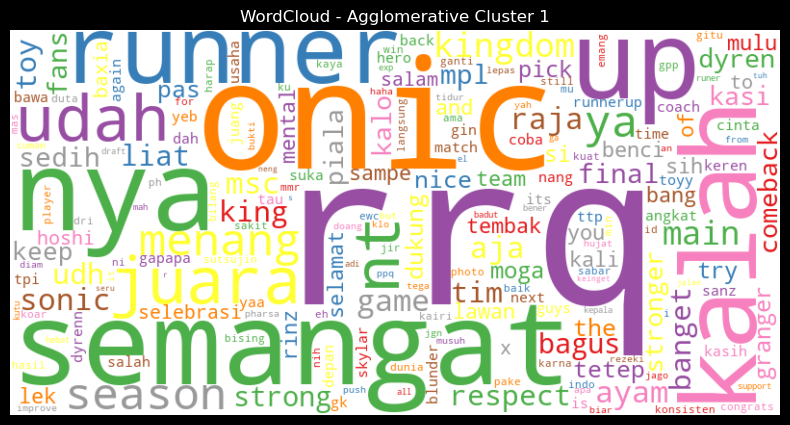

In [32]:
# === Top Words WordCloud untuk Agglomerative ===
print("\n=== WordCloud per Cluster (Agglomerative Clustering) ===")
clusters_agglo = sorted(df['cluster_agglo'].unique())

for cluster_id in clusters_agglo:
    print(f"\nCluster {cluster_id}:")
    
    tokens_in_cluster = df[df['cluster_agglo'] == cluster_id]['tokens'].tolist()
    all_words = sum(tokens_in_cluster, [])
    word_freq = Counter(all_words)

    # Buat WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Set1').generate_from_frequencies(word_freq)

    # Tampilkan WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - Agglomerative Cluster {cluster_id}")
    plt.show()

### TOP WORDS K-MEANS


=== WordCloud per Cluster (KMeans) ===

Cluster 0:


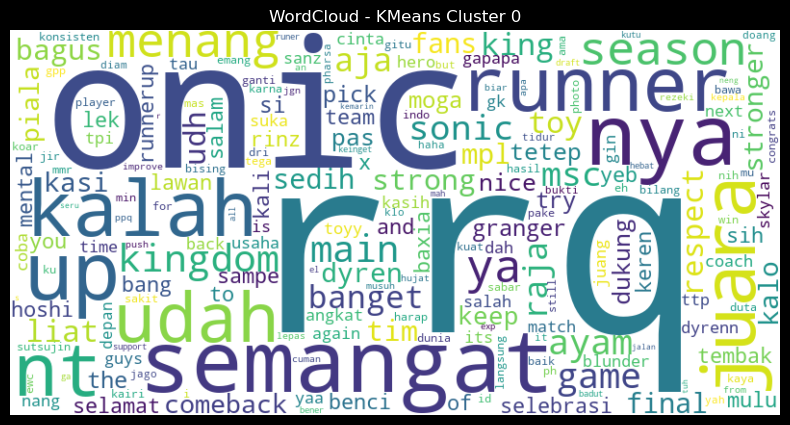


Cluster 1:


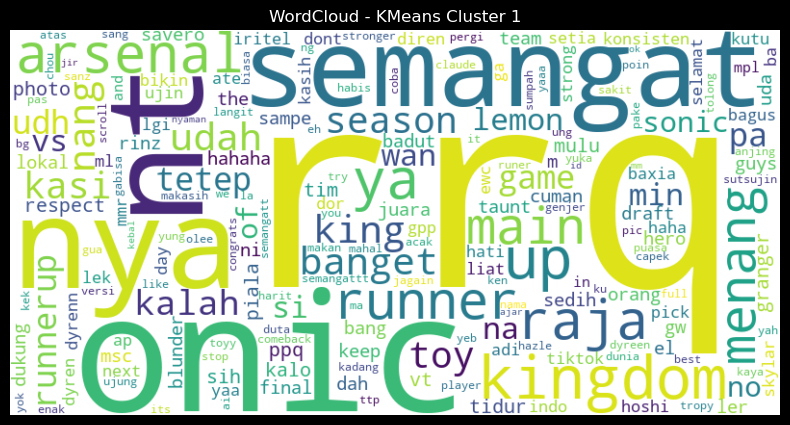

In [33]:
# === WordCloud untuk KMeans ===
print("\n=== WordCloud per Cluster (KMeans) ===")
for cluster_id in sorted(df['cluster_kmeans'].unique()):
    print(f"\nCluster {cluster_id}:")

    tokens_in_cluster = df[df['cluster_kmeans'] == cluster_id]['tokens'].tolist()
    all_words = sum(tokens_in_cluster, [])
    word_freq = Counter(all_words)

    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate_from_frequencies(word_freq)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - KMeans Cluster {cluster_id}")
    plt.show()


### TOP WORDS FUZZY C-MEANS


=== WordCloud per Cluster (Fuzzy C-Means) ===

Cluster 0:


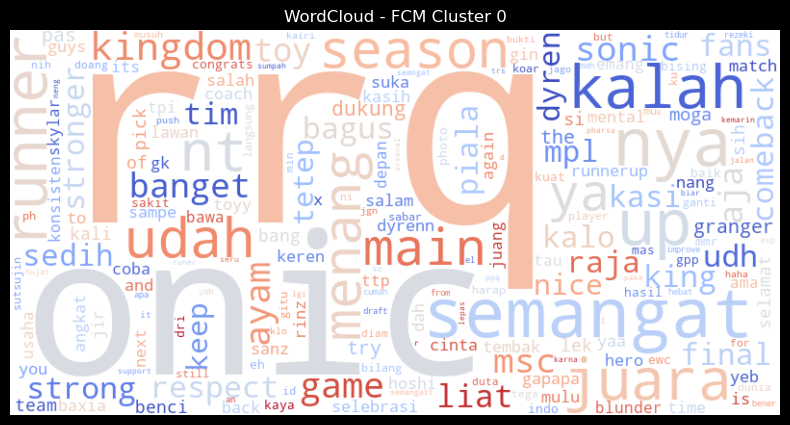


Cluster 1:


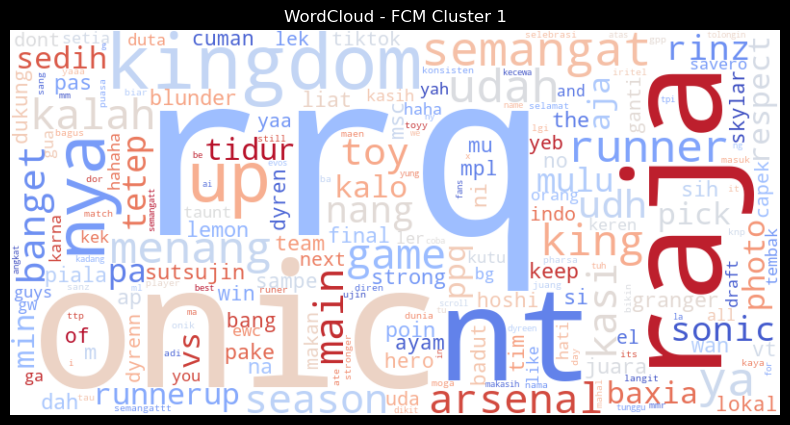

In [34]:
# === WordCloud untuk Fuzzy C-Means ===
print("\n=== WordCloud per Cluster (Fuzzy C-Means) ===")
for cluster_id in sorted(np.unique(df['cluster_fcm'])):
    print(f"\nCluster {cluster_id}:")

    tokens_in_cluster = df[df['cluster_fcm'] == cluster_id]['tokens'].tolist()
    all_words = sum(tokens_in_cluster, [])
    word_freq = Counter(all_words)

    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='coolwarm').generate_from_frequencies(word_freq)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - FCM Cluster {cluster_id}")
    plt.show()